In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt 
import importlib
import portfolio
import market_data
import models
import arch

my_modules = [portfolio, market_data, models]

for module in  my_modules:
    importlib.reload(module)


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

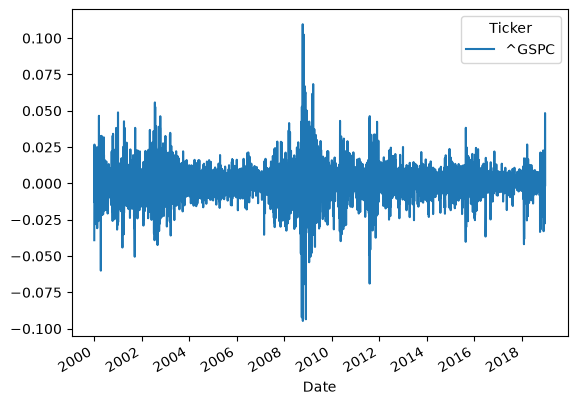

In [4]:
port = portfolio.Portfolio(
    holdings={
        "^GSPC": 1,
        # "MSFT": 3
    }
)

data = market_data.MarketData.from_yfinance(
    port.assets,
    "2000-01-01",
    "2018-12-31",
)

risk_factors = port.risk_factors(data)

risk_factors.plot()

Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10         NaN
                ...   
2018-12-21    0.000176
2018-12-24    0.000186
2018-12-26    0.000209
2018-12-27    0.000294
2018-12-28    0.000285
Name: ^GSPC, Length: 4777, dtype: float64


<Axes: xlabel='Date'>

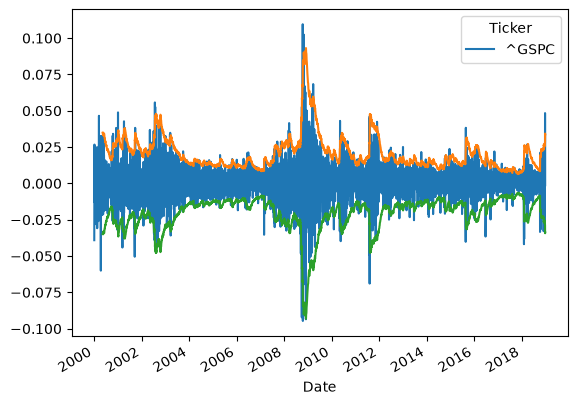

In [5]:
result = models.univariate_ewma_variance_estimator(
    risk_factors
)

# print(result)
print(result.variances)
risk_factors.plot()
(2*np.sqrt(result.variances)).plot()
(-2*np.sqrt(result.variances)).plot()

In [82]:
returns = 100*risk_factors

am = arch.arch_model(returns, mean = 'Zero', vol='Garch', p=1, o=0, q=1, dist='Normal')
garch1_1 = am.fit(update_freq=1, last_obs="2017-12-31") # disp = "off")

Iteration:      1,   Func. Count:      5,   Neg. LLF: 355614029.20326847
Iteration:      2,   Func. Count:     11,   Neg. LLF: 8947.949782482541
Iteration:      3,   Func. Count:     17,   Neg. LLF: 6274.7079982503255
Iteration:      4,   Func. Count:     22,   Neg. LLF: 6267.5612824364
Iteration:      5,   Func. Count:     27,   Neg. LLF: 6211.153159588101
Iteration:      6,   Func. Count:     32,   Neg. LLF: 6354.082907911479
Iteration:      7,   Func. Count:     37,   Neg. LLF: 6204.913870751431
Iteration:      8,   Func. Count:     42,   Neg. LLF: 6204.622026498167
Iteration:      9,   Func. Count:     46,   Neg. LLF: 6204.577116736913
Iteration:     10,   Func. Count:     50,   Neg. LLF: 6204.576878657417
Iteration:     11,   Func. Count:     54,   Neg. LLF: 6204.576871124176
Iteration:     12,   Func. Count:     57,   Neg. LLF: 6204.576871125324
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6204.576871124176
            Iterations: 12
 

In [83]:
print("GARCH(1,1) model:", "\n", garch1_1.summary(), "\n")

GARCH(1,1) model: 
                        Zero Mean - GARCH Model Results                        
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6204.58
Distribution:                  Normal   AIC:                           12415.2
Method:            Maximum Likelihood   BIC:                           12434.4
                                        No. Observations:                 4527
Date:                Wed, Sep 16 2026   Df Residuals:                     4527
Time:                        11:23:57   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0152  4.375e-03      

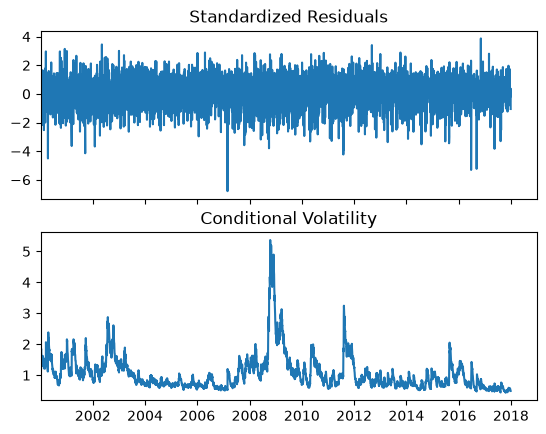

In [84]:
garch1_1.plot()
plt.show()
plt.close()


<Axes: xlabel='Date'>

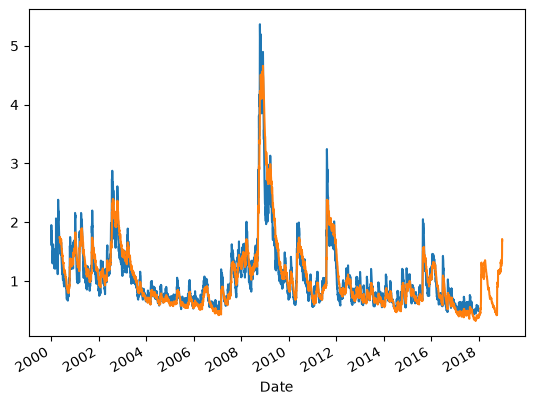

In [87]:
# (returns).plot()
(garch1_1.conditional_volatility).plot()
(100*np.sqrt(result.variances)).plot()

In [92]:
forecasts = garch1_1.forecast(align="target")
cond_var = forecasts.variance["2018":].dropna()
print(cond_var)
q = am.distribution.ppf([0.01, 0.05])
print(q)

                 h.1
Date                
2018-01-02  0.256713
2018-01-03  0.309160
2018-01-04  0.329785
2018-01-05  0.324996
2018-01-08  0.351920
...              ...
2018-12-21  1.936445
2018-12-24  2.154195
2018-12-26  2.654160
2018-12-27  4.603209
2018-12-28  4.194957

[250 rows x 1 columns]
[-2.32634787 -1.64485363]


KeyError: Timestamp('2018-01-02 00:00:00')

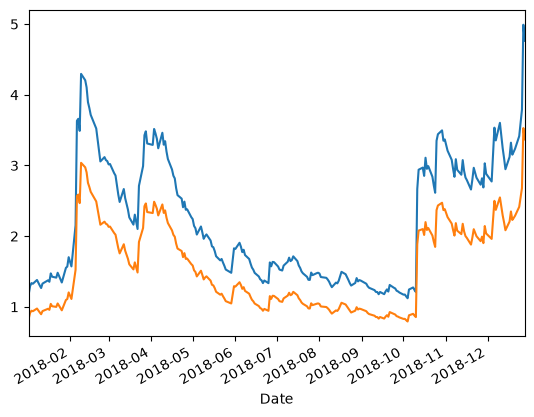

In [ ]:
value_at_risk = - np.sqrt(cond_var).values * q[None, :]
value_at_risk = pd.DataFrame(value_at_risk, columns=["1%", "5%"], index=cond_var.index)
ax = value_at_risk.plot(legend=False)
xl = ax.set_xlim(value_at_risk.index[0], value_at_risk.index[-1])

# print(value_at_risk)

rets_2018 = returns["2018":].copy()
rets_2018.name = "S&P 500 Return"

# print(-value_at_risk.loc[value_at_risk.index[0], "5%"])
# print(value_at_risk.index[0])
# print(rets_2018.index[0])
# print(rets_2018.loc[value_at_risk.index[0]])


c = []
c = []

for idx in value_at_risk.index:
    if rets_2018.loc[idx] > -value_at_risk.loc[idx, "5%"]:
        c.append("#000000")
    elif rets_2018.loc[idx] < -value_at_risk.loc[idx, "1%"]:
        c.append("#BB0000")
    else:
        c.append("#BB00BB")
c = np.array(c, dtype="object")
labels = {
    "#BB0000": "1% Exceedence",
    "#BB00BB": "5% Exceedence",
    "#000000": "No Exceedence",
}
markers = {"#BB0000": "x", "#BB00BB": "s", "#000000": "o"}
for color in np.unique(c):
    sel = c == color
    ax.scatter(
        rets_2018.index[sel],
        -rets_2018.loc[sel],
        marker=markers[color],
        c=c[sel],
        label=labels[color],
    )
ax.set_title("Parametric VaR")
leg = ax.legend(frameon=False, ncol=3)
